# Objetivo 4: Predicción del Coste Esperado del Seguro de Protección de Pagos

## Objetivo

Desarrollar un modelo predictivo para estimar el coste esperado del seguro de protección de pagos en función de las características del prestatario y la probabilidad de impago estimada en el Objetivo 3.

## Metodología

Se implementará una estrategia experimental exhaustiva evaluando:
- **10 modelos de regresión** (desde lineales hasta ensambles)
- **4 configuraciones de reducción dimensional** (Sin PCA, PCA 95%, PCA 99%, PCA fijo)
- **2 estrategias de encoding** (One-Hot, Target Encoding regularizado)
- **Total: 80 experimentos**

## Prevención de Overfitting

1. **Validación cruzada estratificada** (5-fold)
2. **Validación cruzada anidada** para target encoding
3. **Train/Validation/Test split** (60/20/20)
4. **Regularización** en modelos aplicables
5. **Early stopping** en modelos iterativos
6. **Límites en profundidad** de árboles
7. **Análisis de curvas de aprendizaje**
8. **Monitoreo de gap train-validation**

## 1. Configuración del Entorno

In [1]:
# Librerías de modelado
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet,HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    AdaBoostRegressor,
    StackingRegressor,
    ExtraTreesRegressor
)
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Preprocesamiento
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Validación y métricas
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    KFold,
    GridSearchCV,
    learning_curve
)
from sklearn.metrics import (
    r2_score, 
    mean_squared_error, 
    mean_absolute_error,
    mean_absolute_percentage_error
)

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades
import warnings
from datetime import datetime
import json
import time
import joblib
from datetime import datetime
import os
from scipy.stats import shapiro, levene, anderson, f_oneway
import numpy as np

# Configuración
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

# Estilo de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Configuración completada")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Configuración completada
Fecha de ejecución: 2026-02-24 10:08:30


## 2. Carga y Exploración de Datos

In [ ]:
# Cargar dataset
# NOTA: Ajustar ruta según estructura del proyecto
df = pd.read_csv('Datos/Transformados/Datos_Probabilidad_Impago.csv')

print(f"{'='*70}")
print("INFORMACIÓN DEL DATASET")
print(f"{'='*70}")
print(f"Dimensiones: {df.shape[0]:,} registros × {df.shape[1]} variables")
print(f"\nPrimeras observaciones:")
display(df.head())

print(f"\n{'='*70}")
print("ESTADÍSTICAS DESCRIPTIVAS")
print(f"{'='*70}")
display(df.describe())

INFORMACIÓN DEL DATASET
Dimensiones: 50,844 registros × 25 variables

Primeras observaciones:


,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero,Cluster_KMeans,probabilidad_impago
0,S97R7X,18,16000,5000,397,19,1,8.0600,48,0.1000,0,1,0,0,0,50.1200,1,0,0,0,0,0,1,0,0.6434
1,RLGTBY,50,62116,37278,486,217,3,21.9600,12,0.5500,1,1,0,1,1,800.0000,0,0,0,1,1,0,0,1,0.5293
2,SKE2P9,37,37602,44532,765,150,3,11.2000,60,0.2300,1,1,1,1,0,356.3000,0,0,0,1,1,0,0,1,0.3963
3,E2FB1D,56,67410,23752,643,369,1,21.2400,24,0.1800,1,0,1,0,0,198.7200,1,0,0,0,1,0,0,1,0.4464
4,TKSCGH,35,35930,28440,645,136,3,16.9500,12,0.5500,1,1,1,1,0,484.2000,0,0,1,0,0,0,1,1,0.4684



ESTADÍSTICAS DESCRIPTIVAS


,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Jornada completa,Tipo_Jornada_Laboral_Tiempo parcial,Estado_Civil_Casado,Estado_Civil_Divorciado,Estado_Civil_Soltero,Cluster_KMeans,probabilidad_impago
count,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000,50844.0000
mean,43.5465,41576.9342,19956.1309,574.5759,213.0751,2.4962,13.4672,36.0042,0.2086,0.9292,0.5033,0.5009,0.5032,0.1188,209.3793,0.2501,0.2471,0.2495,0.2533,0.5129,0.1890,0.2981,0.3252,0.4561
std,15.0391,16061.3612,13669.6724,159.1335,151.2273,1.1197,6.6347,17.0039,0.1364,0.9244,0.5000,0.5000,0.5000,0.3236,158.8681,0.4331,0.4313,0.4327,0.4349,0.4998,0.3916,0.4574,0.4685,0.1672
min,18.0000,16000.0000,5000.0000,300.0000,0.0000,1.0000,2.0000,12.0000,0.1000,0.0000,0.0000,0.0000,0.0000,0.0000,12.5800,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0869
25%,31.0000,30471.0000,9834.0000,437.0000,69.0000,1.0000,7.7400,24.0000,0.1000,0.0000,0.0000,0.0000,0.0000,0.0000,93.3300,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3239
50%,43.0000,39200.5000,16712.5000,573.0000,207.0000,2.0000,13.4200,36.0000,0.1500,1.0000,1.0000,1.0000,1.0000,0.0000,164.8150,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.4511
75%,57.0000,50195.0000,26210.0000,713.0000,337.0000,4.0000,19.2300,48.0000,0.2700,1.0000,1.0000,1.0000,1.0000,0.0000,276.3425,1.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,1.0000,0.5833
max,69.0000,120000.0000,80000.0000,849.0000,626.0000,4.0000,25.0000,60.0000,0.5500,3.0000,1.0000,1.0000,1.0000,1.0000,800.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.8877


## 3. Definición de Variables y Limpieza

### Variables a Eliminar (Data Leakage):
- `Impago`: Ya capturado en probabilidad_impago
- `ID`: Identificador sin valor predictivo

In [3]:
# Variables a eliminar
columnas_eliminar = [
    'ID',
    'Impago']

# Eliminar columnas que existen
columnas_a_eliminar_existentes = [col for col in columnas_eliminar if col in df.columns]
df_clean = df.drop(columns=columnas_a_eliminar_existentes)

print(f"{'='*70}")
print("LIMPIEZA DE VARIABLES")
print(f"{'='*70}")
print(f"Variables eliminadas: {columnas_a_eliminar_existentes}")
print(f"\nDimensiones después de limpieza: {df_clean.shape[0]:,} × {df_clean.shape[1]}")

# Verificar que Prima existe
if 'Prima' not in df_clean.columns:
    raise ValueError("ERROR: Variable objetivo 'Prima' no encontrada en el dataset")

# Verificar que probabilidad_impago existe
if 'probabilidad_impago' not in df_clean.columns:
    raise ValueError("ERROR: Variable 'probabilidad_impago' del Objetivo 3 no encontrada")

print(f"\nVariable objetivo 'Prima' verificada")
print(f"Variable 'probabilidad_impago' verificada")

LIMPIEZA DE VARIABLES
Variables eliminadas: ['ID', 'Impago']

Dimensiones después de limpieza: 50,844 × 23

Variable objetivo 'Prima' verificada
Variable 'probabilidad_impago' verificada


## 4. Análisis Exploratorio de la Variable Objetivo

ANÁLISIS DE LA VARIABLE OBJETIVO: PRIMA

Estadísticos:
  Media: 209.38
  Mediana: 164.81
  Desv. Estándar: 158.87
  Mínimo: 12.58
  Máximo: 800.00
  Q1: 93.33
  Q3: 276.34


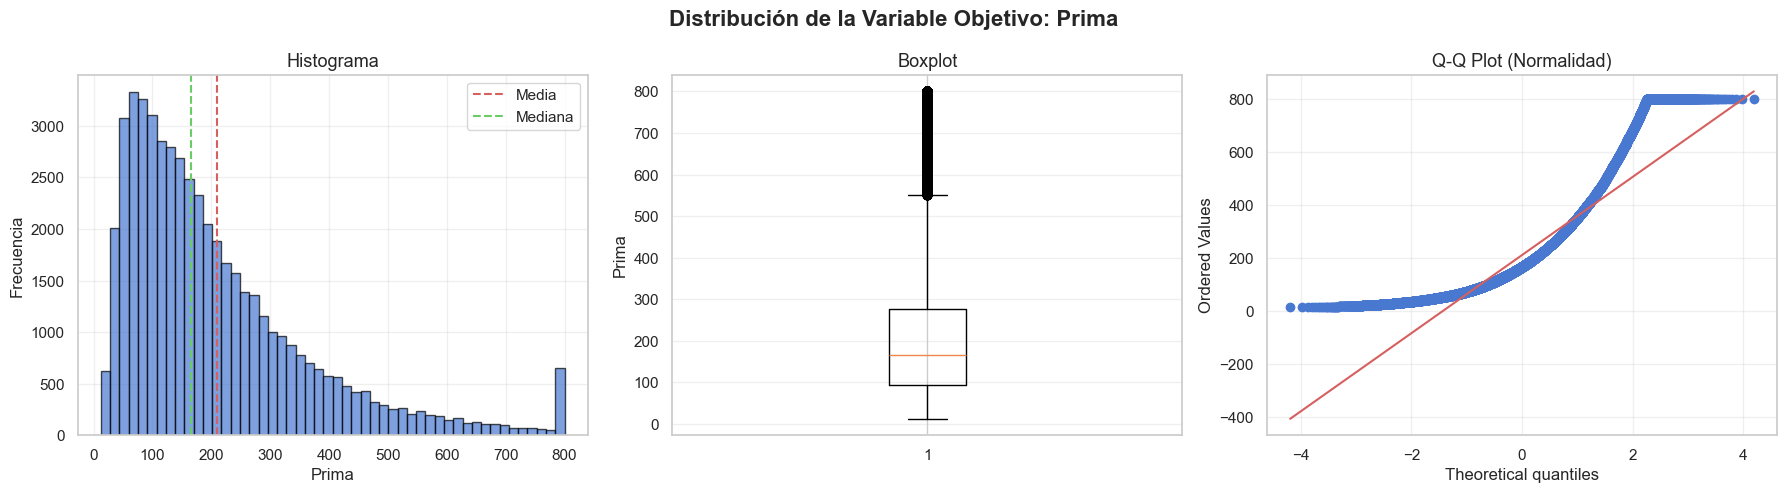


Gráfico guardado: distribucion_prima.png


In [4]:
print(f"{'='*70}")
print("ANÁLISIS DE LA VARIABLE OBJETIVO: PRIMA")
print(f"{'='*70}")
print(f"\nEstadísticos:")
print(f"  Media: {df_clean['Prima'].mean():.2f}")
print(f"  Mediana: {df_clean['Prima'].median():.2f}")
print(f"  Desv. Estándar: {df_clean['Prima'].std():.2f}")
print(f"  Mínimo: {df_clean['Prima'].min():.2f}")
print(f"  Máximo: {df_clean['Prima'].max():.2f}")
print(f"  Q1: {df_clean['Prima'].quantile(0.25):.2f}")
print(f"  Q3: {df_clean['Prima'].quantile(0.75):.2f}")

# Visualización
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de la Variable Objetivo: Prima', fontsize=16, fontweight='bold')

# Histograma
axes[0].hist(df_clean['Prima'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prima', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Histograma', fontsize=13)
axes[0].axvline(df_clean['Prima'].mean(), color='r', linestyle='--', label='Media')
axes[0].axvline(df_clean['Prima'].median(), color='g', linestyle='--', label='Mediana')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df_clean['Prima'], vert=True)
axes[1].set_ylabel('Prima', fontsize=12)
axes[1].set_title('Boxplot', fontsize=13)
axes[1].grid(True, alpha=0.3, axis='y')

# Q-Q plot (normalidad)
from scipy import stats
stats.probplot(df_clean['Prima'], dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot (Normalidad)', fontsize=13)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGráfico guardado: distribucion_prima.png")

## 5. Separación de Variables Numéricas y Categóricas

In [5]:
# Separar variable objetivo
y = df_clean['Prima'].copy()
X = df_clean.drop(columns=['Prima'])

# Identificar variables categóricas (columnas que empiezan con prefijos conocidos o tienen pocos valores únicos)
categorical_features = []
numerical_features = []

for col in X.columns:
    # Variables ya en formato One-Hot (binarias 0/1)
    if col.startswith('Tipo_Jornada_Laboral_') or col.startswith('Estado_Civil_'):
        categorical_features.append(col)
    # Variables ordinales o binarias que son numéricas
    elif col in ['Estudios', 'Posesion_Hipoteca', 'Personas_Cargo', 'Fiador']:
        numerical_features.append(col)
    # Cluster (si existe y no fue eliminado)
    elif 'Cluster' in col:
        categorical_features.append(col)
    # Resto son numéricas continuas
    else:
        numerical_features.append(col)

print(f"{'='*70}")
print("CLASIFICACIÓN DE VARIABLES")
print(f"{'='*70}")
print(f"\nVariables numéricas ({len(numerical_features)}):")
for var in numerical_features:
    print(f"  - {var}")

print(f"\nVariables categóricas ({len(categorical_features)}):")
for var in categorical_features:
    print(f"  - {var}")

print(f"\nTotal features: {len(numerical_features) + len(categorical_features)}")
print(f"Variable objetivo: Prima")

CLASIFICACIÓN DE VARIABLES

Variables numéricas (14):
  - Edad
  - Ingresos
  - Monto_Inicial
  - Scoring_Crediticio
  - Meses_Empleo
  - Num_Creditos
  - Ratio_Interes
  - Duracion
  - Ratio_Deuda_Ingresos
  - Estudios
  - Posesion_Hipoteca
  - Personas_Cargo
  - Fiador
  - probabilidad_impago

Variables categóricas (8):
  - Tipo_Jornada_Laboral_Autónomo
  - Tipo_Jornada_Laboral_Desempleado
  - Tipo_Jornada_Laboral_Jornada completa
  - Tipo_Jornada_Laboral_Tiempo parcial
  - Estado_Civil_Casado
  - Estado_Civil_Divorciado
  - Estado_Civil_Soltero
  - Cluster_KMeans

Total features: 22
Variable objetivo: Prima


## 6. División Train/Validation/Test

División estratégica para prevención de overfitting:
- **Train: 60%** - Entrenamiento y validación cruzada
- **Validation: 20%** - Selección de hiperparámetros
- **Test: 20%** - Evaluación final (NUNCA tocado hasta el final)

In [6]:
# Primera división: Train+Val (80%) vs Test (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Segunda división: Train (60% del total) vs Validation (20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42  # 0.25 * 0.80 = 0.20
)

print(f"{'='*70}")
print("DIVISIÓN DE DATOS")
print(f"{'='*70}")
print(f"\nConjunto de entrenamiento:")
print(f"  X_train: {X_train.shape[0]:,} observaciones ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  y_train: {y_train.shape[0]:,} observaciones")
print(f"  Media Prima: {y_train.mean():.2f}")

print(f"\nConjunto de validación:")
print(f"  X_val: {X_val.shape[0]:,} observaciones ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  y_val: {y_val.shape[0]:,} observaciones")
print(f"  Media Prima: {y_val.mean():.2f}")

print(f"\nConjunto de test (RESERVADO):")
print(f"  X_test: {X_test.shape[0]:,} observaciones ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  y_test: {y_test.shape[0]:,} observaciones")
print(f"  Media Prima: {y_test.mean():.2f}")

print(f"\nTOTAL: {len(X):,} observaciones")

DIVISIÓN DE DATOS

Conjunto de entrenamiento:
  X_train: 30,506 observaciones (60.0%)
  y_train: 30,506 observaciones
  Media Prima: 209.75

Conjunto de validación:
  X_val: 10,169 observaciones (20.0%)
  y_val: 10,169 observaciones
  Media Prima: 210.05

Conjunto de test (RESERVADO):
  X_test: 10,169 observaciones (20.0%)
  y_test: 10,169 observaciones
  Media Prima: 207.59

TOTAL: 50,844 observaciones


## 7. Definición de Configuraciones Experimentales

Grid de experimentos: 4 (reducción) × 2 (encoding) × 10 (modelos) = 80 experimentos

In [7]:
# ============================================
# CONFIGURACIONES DE REDUCCIÓN DIMENSIONAL
# ============================================

reduccion_configs = {
    'sin_pca': {'use_pca': False, 'n_components': None},
    'pca_95': {'use_pca': True, 'n_components': 0.95},
    'pca_99': {'use_pca': True, 'n_components': 0.99},
    'pca_10': {'use_pca': True, 'n_components': 10}
}

# ============================================
# CONFIGURACIONES DE ENCODING
# ============================================

encoding_configs = {
    'ohe': 'one_hot'
}

# ============================================
# CONFIGURACIONES DE MODELOS
# ============================================

# Configuración anti-overfitting integrada en cada modelo
modelo_configs = {
    'linear': {
        'name': 'Regresión Lineal',
        'model': LinearRegression(),
        'param_grid': {}
    },
    'ridge': {
        'name': 'Ridge',
        'model': Ridge(random_state=42),
        'param_grid': {
            'alpha': [0.01, 0.1, 1, 10, 100]  # Regularización L2
        }
    },
    'lasso': {
        'name': 'Lasso',
        'model': Lasso(random_state=42, max_iter=10000),
        'param_grid': {
            'alpha': [0.001, 0.01, 0.1, 1, 10]  # Regularización L1
        }
    },
    'elastic': {
        'name': 'Elastic Net',
        'model': ElasticNet(random_state=42, max_iter=10000),
        'param_grid': {
            'alpha': [0.01, 0.1, 1, 10],
            'l1_ratio': [0.3, 0.5, 0.7]  # Balance L1/L2
        }
    },
    'tree': {
        'name': 'Árbol Decisión',
        'model': DecisionTreeRegressor(random_state=42),
        'param_grid': {
            'max_depth': [3, 5, 7, 10],  # LÍMITE profundidad
            'min_samples_split': [100, 200],  # Mínimo para dividir
            'min_samples_leaf': [50, 100]  # Mínimo en hojas
        }
    },
    'rf': {
        'name': 'Random Forest',
        'model': RandomForestRegressor(random_state=42, n_jobs=-1),
        'param_grid': {
            'n_estimators': [100, 200],
            'max_depth': [10, 15, 20],  # LÍMITE profundidad
            'min_samples_leaf': [20, 50],  # Anti-overfitting
            'max_features': ['sqrt', 0.5]  # Subset features
        }
    },
    'gb': {
        'name': 'Gradient Boosting',
        'model': GradientBoostingRegressor(random_state=42),
        'param_grid': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],  # Tasa aprendizaje baja
            'max_depth': [3, 5],  # Árboles poco profundos
            'subsample': [0.8]  # Fracción datos por árbol
        }
    },
    'xgb': {
        'name': 'XGBoost',
        'model': XGBRegressor(random_state=42, n_jobs=-1),
        'param_grid': {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.05, 0.1],
            'max_depth': [3, 5, 7],
            'reg_alpha': [0, 0.1],  # Regularización L1
            'reg_lambda': [1, 10]  # Regularización L2
        }
    },
    'ada': {
        'name': 'AdaBoost',
        'model': AdaBoostRegressor(
            estimator=DecisionTreeRegressor(max_depth=3, random_state=42),
            random_state=42
        ),
        'param_grid': {
            'n_estimators': [50, 100],
            'learning_rate': [0.01, 0.1, 0.5]
        }
    },
    'huber': {
        'name': 'Huber',
        'model': HuberRegressor(max_iter=1000),
        'param_grid': {'epsilon': [1.1, 1.35, 1.5, 2.0], 'alpha': [0.0001, 0.001, 0.01]}
    },
    'lgbm': {
        'name': 'LightGBM',
        'model': LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        'param_grid': {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7]}
    },
    'extratrees': {
        'name': 'ExtraTrees',
        'model': ExtraTreesRegressor(random_state=42, n_jobs=-1),
        'param_grid': {'n_estimators': [100, 200], 'max_depth': [10, 15, 20], 'min_samples_leaf': [20, 50]}
    }
}

print(f"{'='*70}")
print("CONFIGURACIÓN EXPERIMENTAL")
print(f"{'='*70}")
print(f"\nReducción dimensional: {len(reduccion_configs)} configuraciones")
for key, config in reduccion_configs.items():
    print(f"  - {key}: {config}")

print(f"\nEncoding: {len(encoding_configs)} configuraciones")
for key, config in encoding_configs.items():
    print(f"  - {key}: {config}")

print(f"\nModelos: {len(modelo_configs)} algoritmos")
for key, config in modelo_configs.items():
    n_params = len(config['param_grid'])
    print(f"  - {key}: {config['name']} ({n_params} hiperparámetros)")

total_experimentos = len(reduccion_configs) * len(encoding_configs) * len(modelo_configs)
print(f"\nTOTAL EXPERIMENTOS: {total_experimentos}")

CONFIGURACIÓN EXPERIMENTAL

Reducción dimensional: 4 configuraciones
  - sin_pca: {'use_pca': False, 'n_components': None}
  - pca_95: {'use_pca': True, 'n_components': 0.95}
  - pca_99: {'use_pca': True, 'n_components': 0.99}
  - pca_10: {'use_pca': True, 'n_components': 10}

Encoding: 1 configuraciones
  - ohe: one_hot

Modelos: 12 algoritmos
  - linear: Regresión Lineal (0 hiperparámetros)
  - ridge: Ridge (1 hiperparámetros)
  - lasso: Lasso (1 hiperparámetros)
  - elastic: Elastic Net (2 hiperparámetros)
  - tree: Árbol Decisión (3 hiperparámetros)
  - rf: Random Forest (4 hiperparámetros)
  - gb: Gradient Boosting (4 hiperparámetros)
  - xgb: XGBoost (5 hiperparámetros)
  - ada: AdaBoost (2 hiperparámetros)
  - huber: Huber (2 hiperparámetros)
  - lgbm: LightGBM (3 hiperparámetros)
  - extratrees: ExtraTrees (3 hiperparámetros)

TOTAL EXPERIMENTOS: 48


## 8. Función de Target Encoding Regularizado (Anti-Overfitting)

In [8]:
def target_encoding_regularizado(X_train, y_train, X_val, categorical_cols, m=10):
    """
    Target encoding con regularización para evitar overfitting.
    
    Como tu dataset tiene variables categóricas YA en formato OHE (0/1),
    esta función simplemente RETORNA LOS DATOS SIN MODIFICAR.
    
    Parámetros:
    -----------
    X_train : DataFrame
        Conjunto de entrenamiento
    y_train : Series
        Variable objetivo de entrenamiento
    X_val : DataFrame
        Conjunto de validación
    categorical_cols : list
        Lista de columnas categóricas a codificar
    m : int
        Parámetro de suavizado (mayor = más conservador)
    
    Retorna:
    --------
    X_train_encoded, X_val_encoded : DataFrames (sin cambios en este caso)
    encoding_maps : dict vacío
    """
    
    # VERIFICAR: ¿Las columnas categóricas son binarias (0/1)?
    # Si sí, NO aplicar target encoding (no tiene sentido)
    
    todas_binarias = True
    for col in categorical_cols:
        valores_unicos = X_train[col].nunique()
        if valores_unicos > 2:
            todas_binarias = False
            break
    
    if todas_binarias:
        # Variables YA están en formato OHE (0/1), no hacer nada
        print("  [INFO] Variables categóricas ya están en formato One-Hot (0/1)")
        print("  [INFO] Target encoding NO aplicable, retornando datos sin cambios")
        return X_train.copy(), X_val.copy(), {}
    
    # Si llegamos aquí, hay variables categóricas verdaderas
    # Aplicar target encoding regularizado
    
    X_train_encoded = X_train.copy()
    X_val_encoded = X_val.copy()
    
    # Media global del target
    mean_global = y_train.mean()
    
    encoding_maps = {}
    
    for col in categorical_cols:
        # Crear DataFrame temporal para cálculos
        temp_df = pd.DataFrame({
            'categoria': X_train_encoded[col],
            'target': y_train
        })
        
        # Calcular estadísticas por categoría
        stats = temp_df.groupby('categoria')['target'].agg(['mean', 'count']).reset_index()
        stats.columns = ['categoria', 'mean_cat', 'n_cat']
        
        # Aplicar fórmula de suavizado
        stats['encoded'] = (
            (stats['n_cat'] * stats['mean_cat'] + m * mean_global) / 
            (stats['n_cat'] + m)
        )
        
        # Crear diccionario de mapeo
        encoding_map = dict(zip(stats['categoria'], stats['encoded']))
        encoding_maps[col] = encoding_map
        
        # Aplicar encoding
        X_train_encoded[col + '_encoded'] = X_train_encoded[col].map(encoding_map).fillna(mean_global)
        X_val_encoded[col + '_encoded'] = X_val_encoded[col].map(encoding_map).fillna(mean_global)
        
        # Eliminar columna original
        X_train_encoded = X_train_encoded.drop(columns=[col])
        X_val_encoded = X_val_encoded.drop(columns=[col])
    
    return X_train_encoded, X_val_encoded, encoding_maps

print("Función de target encoding regularizado definida (CORREGIDA)")

Función de target encoding regularizado definida (CORREGIDA)


## 9. Función de Preprocesamiento (Pipeline Modular)

In [9]:
def preprocesar_datos(X_train, X_val, y_train, reduccion_config, encoding_type):
    """
    Preprocesa los datos según configuración especificada.
    
    Pasos:
    1. Encoding de categóricas (OHE o Target)
    2. Estandarización
    3. PCA (opcional)
    
    Retorna:
    --------
    X_train_processed, X_val_processed, scaler, pca (si aplica)
    """
    X_train_proc = X_train.copy()
    X_val_proc = X_val.copy()
    
    # PASO 1: ENCODING
    if encoding_type == 'one_hot':
        # One-Hot Encoding (las categóricas ya están en formato 0/1, no hacer nada)
        pass
    
    elif encoding_type == 'target_encoding':
        # Target encoding regularizado
        if len(categorical_features) > 0:
            X_train_proc, X_val_proc, _ = target_encoding_regularizado(
                X_train_proc, y_train, X_val_proc, categorical_features, m=10
            )
    
    # PASO 2: ESTANDARIZACIÓN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_proc)
    X_val_scaled = scaler.transform(X_val_proc)
    
    # PASO 3: PCA (opcional)
    pca = None
    if reduccion_config['use_pca']:
        n_comp = reduccion_config['n_components']
        pca = PCA(n_components=n_comp, random_state=42)
        X_train_scaled = pca.fit_transform(X_train_scaled)
        X_val_scaled = pca.transform(X_val_scaled)
    
    return X_train_scaled, X_val_scaled, scaler, pca

print("Función de preprocesamiento definida")

Función de preprocesamiento definida


## 10. Función de Evaluación de Modelos

In [10]:
def evaluar_modelo(y_true, y_pred, conjunto_nombre=''):
    """
    Calcula métricas de regresión.
    
    Retorna:
    --------
    dict con métricas: R2, R2_ajustado, RMSE, MAE, MAPE
    """
    n = len(y_true)
    
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    
    # MAPE (cuidado con divisiones por cero)
    try:
        mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    except:
        mape = np.nan
    
    # R² ajustado (requiere conocer p = número de features)
    # Lo calcularemos después cuando tengamos el modelo
    
    metricas = {
        'r2': r2,
        'rmse': rmse,
        'mae': mae,
        'mape': mape
    }
    
    return metricas

print("Función de evaluación definida")

Función de evaluación definida


In [11]:
tiempo_inicio_exp=time.time()

tiempo_fin_exp=time.time()
duracion_exp = tiempo_fin_exp - tiempo_inicio_exp
duracion_exp

0.0

## 11. Ejecución de Experimentos (Grid Completo)

Este proceso puede tardar considerable tiempo. Los resultados se guardan progresivamente.

In [12]:
# Almacenar resultados
resultados_experimentos = []

# Contador de experimentos
exp_id = 0

print(f"{'='*70}")
print("INICIO DE EXPERIMENTOS")
print(f"{'='*70}")
print(f"Total de experimentos a ejecutar: {total_experimentos}")
print(f"Estrategia anti-overfitting:")
print(f"  - Validación cruzada 5-fold en train")
print(f"  - Evaluación en conjunto de validación separado")
print(f"  - Conjunto de test RESERVADO para evaluación final")
print(f"\nIniciando ejecución...\n")

# LOOP 1: Reducción dimensional
for red_key, red_config in reduccion_configs.items():
    
    # LOOP 2: Encoding
    for enc_key, enc_type in encoding_configs.items():
        
        print(f"\n{'─'*70}")
        print(f"PREPROCESAMIENTO:")
        print(f"{'─'*70}")
        
        # Preprocesar datos
        X_train_prep, X_val_prep, scaler, pca = preprocesar_datos(
            X_train, X_val, y_train, red_config, enc_type
        )
        
        # Información de preprocesamiento
        print(f"Dimensiones después de preprocesamiento:")
        print(f"  Train: {X_train_prep.shape}")
        print(f"  Validation: {X_val_prep.shape}")
        
        if pca is not None:
            var_exp = pca.explained_variance_ratio_.sum()
            n_comp = pca.n_components_
            print(f"  PCA: {n_comp} componentes, {var_exp*100:.2f}% varianza explicada")
        
        # LOOP 3: Modelos
        for mod_key, mod_config in modelo_configs.items():
            exp_id += 1
            tiempo_inicio_exp = time.time()
            print(f"\n  [{exp_id:3d}/{total_experimentos}] {mod_config['name']}...", end=' ')
            
            try:
                # GridSearchCV con validación cruzada
                cv = KFold(n_splits=5, shuffle=True, random_state=42)
                
                if len(mod_config['param_grid']) > 0:
                    # Búsqueda de hiperparámetros
                    grid_search = GridSearchCV(
                        estimator=mod_config['model'],
                        param_grid=mod_config['param_grid'],
                        cv=cv,
                        scoring='r2',
                        n_jobs=-1,
                        verbose=0
                    )
                    grid_search.fit(X_train_prep, y_train)
                    
                    # Mejor modelo
                    modelo = grid_search.best_estimator_
                    best_params = grid_search.best_params_
                    cv_r2_train = grid_search.best_score_
                else:
                    # Modelo sin hiperparámetros (LinearRegression)
                    modelo = mod_config['model']
                    modelo.fit(X_train_prep, y_train)
                    best_params = {}
                    
                    # Calcular R2 en CV manualmente
                    cv_scores = cross_val_score(
                        modelo, X_train_prep, y_train, cv=cv, scoring='r2'
                    )
                    cv_r2_train = cv_scores.mean()
                
                # Predicciones
                y_train_pred = modelo.predict(X_train_prep)
                y_val_pred = modelo.predict(X_val_prep)
                
                # Métricas en Train
                metricas_train = evaluar_modelo(y_train, y_train_pred, 'Train')
                
                # Métricas en Validation
                metricas_val = evaluar_modelo(y_val, y_val_pred, 'Validation')
                
                # GAP Train-Validation (indicador de overfitting)
                gap_r2 = metricas_train['r2'] - metricas_val['r2']
                
                #tiempo ejecucion
                tiempo_fin_exp = time.time() 
                duracion_exp = tiempo_fin_exp - tiempo_inicio_exp

                # Almacenar resultados
                resultado = {
                    'exp_id': exp_id,
                    'reduccion': red_key,
                    'encoding': enc_key,
                    'modelo': mod_key,
                    'modelo_nombre': mod_config['name'],
                    'best_params': str(best_params),
                    'n_features': X_train_prep.shape[1],
                    
                    # Métricas Train
                    'train_r2': metricas_train['r2'],
                    'train_rmse': metricas_train['rmse'],
                    'train_mae': metricas_train['mae'],
                    'train_mape': metricas_train['mape'],
                    
                    # Métricas Validation
                    'val_r2': metricas_val['r2'],
                    'val_rmse': metricas_val['rmse'],
                    'val_mae': metricas_val['mae'],
                    'val_mape': metricas_val['mape'],
                    
                    # Indicadores de overfitting
                    'cv_r2_train': cv_r2_train,
                    'gap_r2_train_val': gap_r2,
                    
                    #Duracion de cada modelo
                    'duracion_segundos': duracion_exp
                }
                
                resultados_experimentos.append(resultado)
                
                print(f"R²_val={metricas_val['r2']:.4f}, GAP={gap_r2:.4f}, TIEMPO={duracion_exp:.1f}s")
                
            except Exception as e:
                print(f"ERROR: {str(e)}")
                continue

print(f"\n{'='*70}")
print("EXPERIMENTOS COMPLETADOS")
print(f"{'='*70}")
print(f"Total de experimentos ejecutados: {len(resultados_experimentos)}")

INICIO DE EXPERIMENTOS
Total de experimentos a ejecutar: 48
Estrategia anti-overfitting:
  - Validación cruzada 5-fold en train
  - Evaluación en conjunto de validación separado
  - Conjunto de test RESERVADO para evaluación final

Iniciando ejecución...


──────────────────────────────────────────────────────────────────────
PREPROCESAMIENTO:
──────────────────────────────────────────────────────────────────────
Dimensiones después de preprocesamiento:
  Train: (30506, 22)
  Validation: (10169, 22)

  [  1/48] Regresión Lineal... R²_val=0.8442, GAP=0.0031, TIEMPO=0.1s

  [  2/48] Ridge... R²_val=0.8442, GAP=0.0031, TIEMPO=5.1s

  [  3/48] Lasso... R²_val=0.8442, GAP=0.0031, TIEMPO=5.3s

  [  4/48] Elastic Net... R²_val=0.8444, GAP=0.0029, TIEMPO=2.5s

  [  5/48] Árbol Decisión... R²_val=0.9244, GAP=0.0157, TIEMPO=1.4s

  [  6/48] Random Forest... R²_val=0.9527, GAP=0.0120, TIEMPO=65.6s

  [  7/48] Gradient Boosting... R²_val=0.9933, GAP=0.0032, TIEMPO=76.6s

  [  8/48] XGBoost... R²_v

## 12. Análisis de Resultados

In [13]:
# Convertir resultados a DataFrame
df_resultados = pd.DataFrame(resultados_experimentos)

# Ordenar por R² validation (descendente)
df_resultados = df_resultados.sort_values('val_r2', ascending=False).reset_index(drop=True)

print(f"{'='*70}")
print("TOP 20 MODELOS POR R² EN VALIDACIÓN")
print(f"{'='*70}")

# columnas_mostrar = [
#     'exp_id', 'modelo_nombre', 'reduccion', 'encoding',
#     'val_r2', 'val_rmse', 'val_mae', 'gap_r2_train_val'
# ]

display(df_resultados.head(20))#meter columnas a mostrar


TOP 20 MODELOS POR R² EN VALIDACIÓN


,exp_id,reduccion,encoding,modelo,modelo_nombre,best_params,n_features,train_r2,train_rmse,train_mae,train_mape,val_r2,val_rmse,val_mae,val_mape,cv_r2_train,gap_r2_train_val,duracion_segundos
0,11,sin_pca,ohe,lgbm,LightGBM,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",22,0.9968,9.0175,6.0872,3.4508,0.9938,12.5845,7.4650,3.9036,0.9937,0.0029,23.6950
1,8,sin_pca,ohe,xgb,XGBoost,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",22,0.9987,5.6493,4.0264,2.3763,0.9937,12.7097,7.1188,3.3976,0.9933,0.0050,22.7748
2,7,sin_pca,ohe,gb,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",22,0.9965,9.3890,6.3747,3.6441,0.9933,13.1095,7.8142,4.0846,0.9927,0.0032,76.5748
3,12,sin_pca,ohe,extratrees,ExtraTrees,"{'max_depth': 20, 'min_samples_leaf': 20, 'n_e...",22,0.9691,27.9348,17.9474,9.0517,0.9610,31.6757,20.3118,10.2744,0.9593,0.0082,36.1225
4,6,sin_pca,ohe,rf,Random Forest,"{'max_depth': 15, 'max_features': 0.5, 'min_sa...",22,0.9647,29.8800,19.1793,9.8250,0.9527,34.8810,22.4248,11.4583,0.9507,0.0120,65.6115
5,32,pca_99,ohe,xgb,XGBoost,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",17,0.9836,20.3701,14.2571,8.4451,0.9510,35.4912,23.4691,12.6006,0.9485,0.0326,36.4694
6,35,pca_99,ohe,lgbm,LightGBM,"{'learning_rate': 0.1, 'max_depth': 7, 'n_esti...",17,0.9736,25.8375,18.4605,11.1417,0.9503,35.7470,24.0168,13.4688,0.9509,0.0233,20.3128
7,31,pca_99,ohe,gb,Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': 5, 'n_esti...",17,0.9672,28.7963,20.4419,12.4076,0.9435,38.1048,25.7863,14.7622,0.9415,0.0237,202.8030
8,5,sin_pca,ohe,tree,Árbol Decisión,"{'max_depth': 10, 'min_samples_leaf': 50, 'min...",22,0.9400,38.9421,25.1526,12.6761,0.9244,44.0922,28.3293,13.9762,0.9227,0.0157,1.3865
9,4,sin_pca,ohe,elastic,Elastic Net,"{'alpha': 0.01, 'l1_ratio': 0.7}",22,0.8473,62.1346,44.1797,34.7627,0.8444,63.2474,45.6071,36.8488,0.8469,0.0029,2.4942


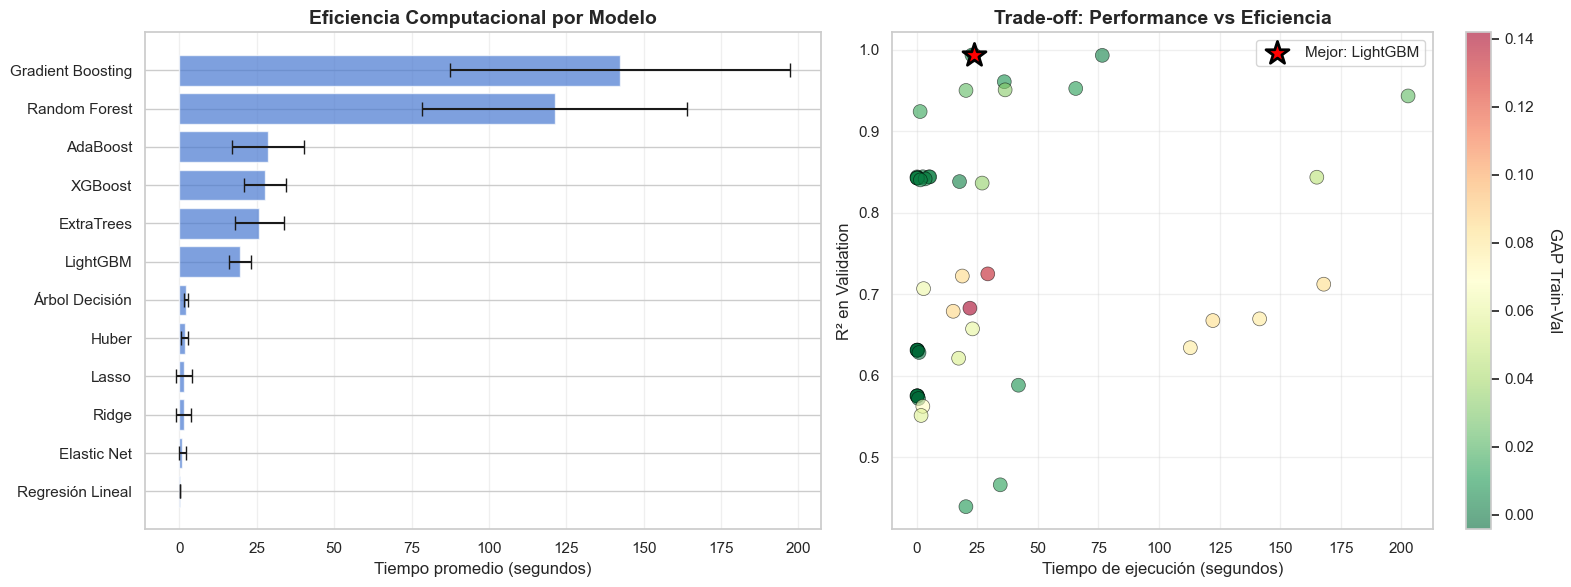


Top 3 modelos más rápidos:
                   mean    std
modelo_nombre                 
Regresión Lineal 0.0770 0.0288
Elastic Net      0.8804 1.0762
Ridge            1.4338 2.4305

Top 3 modelos más lentos:
                      mean     std
modelo_nombre                     
AdaBoost           28.5859 11.5752
Random Forest     121.2937 42.8212
Gradient Boosting 142.3937 54.9056

Tiempo total experimental: 24.9 minutos


In [14]:
# Análisis de eficiencia computacional
import matplotlib.pyplot as plt

# Crear figura con 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Tiempo promedio por modelo
df_tiempo = df_resultados.groupby('modelo_nombre')['duracion_segundos'].agg(['mean', 'std']).sort_values('mean')
axes[0].barh(df_tiempo.index, df_tiempo['mean'], xerr=df_tiempo['std'], alpha=0.7, capsize=5)
axes[0].set_xlabel('Tiempo promedio (segundos)', fontsize=12)
axes[0].set_title('Eficiencia Computacional por Modelo', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Subplot 2: Trade-off Performance vs Tiempo
axes[1].scatter(df_resultados['duracion_segundos'], df_resultados['val_r2'], 
                alpha=0.6, s=100, c=df_resultados['gap_r2_train_val'], 
                cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)
axes[1].set_xlabel('Tiempo de ejecución (segundos)', fontsize=12)
axes[1].set_ylabel('R² en Validation', fontsize=12)
axes[1].set_title('Trade-off: Performance vs Eficiencia', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# Añadir colorbar
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('GAP Train-Val', rotation=270, labelpad=20)

# Marcar el mejor modelo
mejor_idx = df_resultados['val_r2'].idxmax()
mejor = df_resultados.loc[mejor_idx]
axes[1].scatter(mejor['duracion_segundos'], mejor['val_r2'], 
                color='red', s=300, marker='*', edgecolors='black', linewidth=2, 
                label=f"Mejor: {mejor['modelo_nombre']}")
axes[1].legend()

plt.tight_layout()
plt.savefig('eficiencia_computacional_objetivo4.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTop 3 modelos más rápidos:")
print(df_tiempo.head(3))
print(f"\nTop 3 modelos más lentos:")
print(df_tiempo.tail(3))
print(f"\nTiempo total experimental: {df_resultados['duracion_segundos'].sum()/60:.1f} minutos")

## 13. Análisis de Overfitting

Identificar modelos con gap excesivo entre train y validation.

ANÁLISIS DE OVERFITTING

Modelos con indicios de overfitting (GAP > 0.05):
  Total: 13 de 48 (27.1%)

Peores casos de overfitting:


,modelo_nombre,reduccion,encoding,train_r2,val_r2,gap_r2_train_val
26,XGBoost,pca_10,ohe,0.8251,0.6832,0.1419
22,XGBoost,pca_95,ohe,0.8591,0.7252,0.1338
27,LightGBM,pca_10,ohe,0.7656,0.6794,0.0862
23,LightGBM,pca_95,ohe,0.8079,0.7226,0.0853
24,Gradient Boosting,pca_95,ohe,0.7967,0.7126,0.0841
29,Gradient Boosting,pca_10,ohe,0.7518,0.6680,0.0839
28,Random Forest,pca_95,ohe,0.7491,0.6700,0.0791
31,Random Forest,pca_10,ohe,0.7129,0.6347,0.0782
44,Árbol Decisión,pca_95,ohe,0.6318,0.5628,0.0690
25,Árbol Decisión,pca_99,ohe,0.7691,0.7071,0.0620


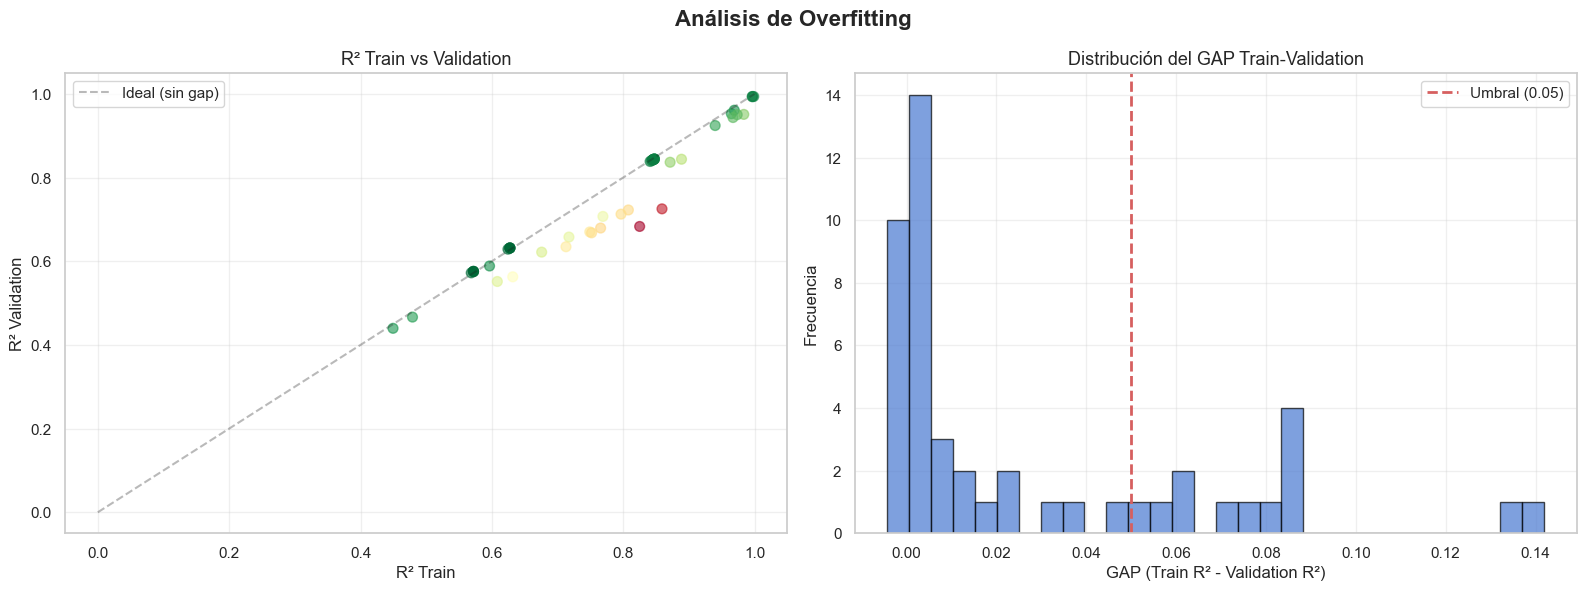


Gráfico guardado: analisis_overfitting.png


In [15]:
print(f"{'='*70}")
print("ANÁLISIS DE OVERFITTING")
print(f"{'='*70}")

# Definir umbral de gap aceptable
umbral_gap = 0.05  # 5% de diferencia aceptable

df_resultados['overfitting'] = df_resultados['gap_r2_train_val'] > umbral_gap

n_overfit = df_resultados['overfitting'].sum()
pct_overfit = (n_overfit / len(df_resultados)) * 100

print(f"\nModelos con indicios de overfitting (GAP > {umbral_gap}):")
print(f"  Total: {n_overfit} de {len(df_resultados)} ({pct_overfit:.1f}%)")

if n_overfit > 0:
    print(f"\nPeores casos de overfitting:")
    overfit_casos = df_resultados[df_resultados['overfitting']].nlargest(10, 'gap_r2_train_val')
    display(overfit_casos[['modelo_nombre', 'reduccion', 'encoding', 'train_r2', 'val_r2', 'gap_r2_train_val']])

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Overfitting', fontsize=16, fontweight='bold')

# Gráfico 1: Train vs Validation R²
axes[0].scatter(
    df_resultados['train_r2'], 
    df_resultados['val_r2'],
    c=df_resultados['gap_r2_train_val'],
    cmap='RdYlGn_r',
    s=50,
    alpha=0.6
)
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Ideal (sin gap)')
axes[0].set_xlabel('R² Train', fontsize=12)
axes[0].set_ylabel('R² Validation', fontsize=12)
axes[0].set_title('R² Train vs Validation', fontsize=13)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Distribución de GAP
axes[1].hist(df_resultados['gap_r2_train_val'], bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(umbral_gap, color='r', linestyle='--', linewidth=2, label=f'Umbral ({umbral_gap})')
axes[1].set_xlabel('GAP (Train R² - Validation R²)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución del GAP Train-Validation', fontsize=13)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGráfico guardado: analisis_overfitting.png")

## 14. Selección del Modelo Final

Criterios de selección:
1. Maximizar R² en validation
2. GAP train-validation < 0.05
3. Parsimonia (menos features si performance similar)

In [16]:
# Filtrar modelos sin overfitting excesivo
df_candidatos = df_resultados[df_resultados['gap_r2_train_val'] <= umbral_gap].copy()

print(f"{'='*70}")
print("SELECCIÓN DE MODELO FINAL")
print(f"{'='*70}")
print(f"\nCandidatos (sin overfitting): {len(df_candidatos)} modelos")

if len(df_candidatos) == 0:
    print("\nADVERTENCIA: Ningún modelo cumple criterio de GAP < 0.05")
    print("Seleccionando entre todos los modelos por R² validation...")
    df_candidatos = df_resultados.copy()

# Ordenar por R² validation
df_candidatos = df_candidatos.sort_values('val_r2', ascending=False)

# Mejor modelo
mejor_modelo_info = df_candidatos.iloc[0]

print(f"\n{'='*70}")
print("MODELO FINAL SELECCIONADO")
print(f"{'='*70}")
print(f"\nExperimento ID: {mejor_modelo_info['exp_id']}")
print(f"Modelo: {mejor_modelo_info['modelo_nombre']}")
print(f"Reducción: {mejor_modelo_info['reduccion']}")
print(f"Encoding: {mejor_modelo_info['encoding']}")
print(f"Features: {mejor_modelo_info['n_features']}")
print(f"Hiperparámetros: {mejor_modelo_info['best_params']}")

print(f"\nMétricas en Validation:")
print(f"  R²: {mejor_modelo_info['val_r2']:.4f}")
print(f"  RMSE: {mejor_modelo_info['val_rmse']:.2f}")
print(f"  MAE: {mejor_modelo_info['val_mae']:.2f}")
print(f"  MAPE: {mejor_modelo_info['val_mape']:.2f}%")

print(f"\nIndicadores de robustez:")
print(f"  GAP Train-Val: {mejor_modelo_info['gap_r2_train_val']:.4f}")
print(f"  CV R² Train: {mejor_modelo_info['cv_r2_train']:.4f}")

# Top 5 para comparación
print(f"\n{'='*70}")
print("TOP 10 MODELOS CANDIDATOS")
print(f"{'='*70}")
display(df_candidatos[[
    'exp_id', 'modelo_nombre', 'reduccion', 'encoding',
    'val_r2', 'val_rmse', 'gap_r2_train_val',"duracion_segundos"
]].head(10))

SELECCIÓN DE MODELO FINAL

Candidatos (sin overfitting): 35 modelos

MODELO FINAL SELECCIONADO

Experimento ID: 11
Modelo: LightGBM
Reducción: sin_pca
Encoding: ohe
Features: 22
Hiperparámetros: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}

Métricas en Validation:
  R²: 0.9938
  RMSE: 12.58
  MAE: 7.46
  MAPE: 3.90%

Indicadores de robustez:
  GAP Train-Val: 0.0029
  CV R² Train: 0.9937

TOP 10 MODELOS CANDIDATOS


,exp_id,modelo_nombre,reduccion,encoding,val_r2,val_rmse,gap_r2_train_val,duracion_segundos
0,11,LightGBM,sin_pca,ohe,0.9938,12.5845,0.0029,23.6950
1,8,XGBoost,sin_pca,ohe,0.9937,12.7097,0.0050,22.7748
2,7,Gradient Boosting,sin_pca,ohe,0.9933,13.1095,0.0032,76.5748
3,12,ExtraTrees,sin_pca,ohe,0.9610,31.6757,0.0082,36.1225
4,6,Random Forest,sin_pca,ohe,0.9527,34.8810,0.0120,65.6115
5,32,XGBoost,pca_99,ohe,0.9510,35.4912,0.0326,36.4694
6,35,LightGBM,pca_99,ohe,0.9503,35.7470,0.0233,20.3128
7,31,Gradient Boosting,pca_99,ohe,0.9435,38.1048,0.0237,202.8030
8,5,Árbol Decisión,sin_pca,ohe,0.9244,44.0922,0.0157,1.3865
9,4,Elastic Net,sin_pca,ohe,0.8444,63.2474,0.0029,2.4942


## 15. Reentrenamiento del Modelo Final y Evaluación en Test

Entrenar el mejor modelo con la configuración óptima y evaluar en el conjunto de test RESERVADO.

In [17]:
print(f"{'='*70}")
print("REENTRENAMIENTO Y EVALUACIÓN FINAL EN TEST")
print(f"{'='*70}")

# Extraer configuración del mejor modelo
mejor_red_key = mejor_modelo_info['reduccion']
mejor_enc_key = mejor_modelo_info['encoding']
mejor_mod_key = mejor_modelo_info['modelo']

mejor_red_config = reduccion_configs[mejor_red_key]
mejor_enc_type = encoding_configs[mejor_enc_key]
mejor_mod_config = modelo_configs[mejor_mod_key]

print(f"\nConfiguración seleccionada:")
print(f"  Reducción: {mejor_red_key}")
print(f"  Encoding: {mejor_enc_key}")
print(f"  Modelo: {mejor_mod_config['name']}")

# Preprocesar train y test con misma configuración
print(f"\nPreprocesando datos...")

# Usar TRAIN + VALIDATION para entrenamiento final
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

# Preprocesar
X_train_final_prep, X_test_prep, scaler_final, pca_final = preprocesar_datos(
    X_train_final, X_test, y_train_final, mejor_red_config, mejor_enc_type
)

print(f"Dimensiones finales:")
print(f"  Train+Val: {X_train_final_prep.shape}")
print(f"  Test: {X_test_prep.shape}")

# Entrenar modelo final
print(f"\nEntrenando modelo final...")

# Parsear hiperparámetros del mejor modelo
import ast
best_params_dict = ast.literal_eval(mejor_modelo_info['best_params'])

# Crear modelo con mejores hiperparámetros
if len(best_params_dict) > 0:
    modelo_final = mejor_mod_config['model'].__class__(**best_params_dict, random_state=42)
else:
    modelo_final = mejor_mod_config['model']

modelo_final.fit(X_train_final_prep, y_train_final)

# Predicciones
y_train_final_pred = modelo_final.predict(X_train_final_prep)
y_test_pred = modelo_final.predict(X_test_prep)

# Métricas finales
metricas_train_final = evaluar_modelo(y_train_final, y_train_final_pred, 'Train+Val')
metricas_test = evaluar_modelo(y_test, y_test_pred, 'Test')

# R² ajustado
n_test = len(y_test)
p = X_test_prep.shape[1]
r2_ajustado_test = 1 - (1 - metricas_test['r2']) * (n_test - 1) / (n_test - p - 1)

print(f"\n{'='*70}")
print("RESULTADOS FINALES")
print(f"{'='*70}")

print(f"\nMétricas en TRAIN+VAL:")
print(f"  R²: {metricas_train_final['r2']:.4f}")
print(f"  RMSE: {metricas_train_final['rmse']:.2f}")
print(f"  MAE: {metricas_train_final['mae']:.2f}")
print(f"  MAPE: {metricas_train_final['mape']:.2f}%")

print(f"\nMétricas en TEST (evaluación final):")
print(f"  R²: {metricas_test['r2']:.4f}")
print(f"  R² ajustado: {r2_ajustado_test:.4f}")
print(f"  RMSE: {metricas_test['rmse']:.2f}")
print(f"  MAE: {metricas_test['mae']:.2f}")
print(f"  MAPE: {metricas_test['mape']:.2f}%")

gap_final = metricas_train_final['r2'] - metricas_test['r2']
print(f"\nGAP Train-Test: {gap_final:.4f}")

if gap_final < 0.05:
    print("Modelo ROBUSTO (gap < 5%)")
elif gap_final < 0.10:
    print("Modelo ACEPTABLE (gap < 10%)")
else:
    print("ADVERTENCIA: Posible overfitting (gap > 10%)")

REENTRENAMIENTO Y EVALUACIÓN FINAL EN TEST

Configuración seleccionada:
  Reducción: sin_pca
  Encoding: ohe
  Modelo: LightGBM

Preprocesando datos...
Dimensiones finales:
  Train+Val: (40675, 22)
  Test: (10169, 22)

Entrenando modelo final...

RESULTADOS FINALES

Métricas en TRAIN+VAL:
  R²: 0.9967
  RMSE: 9.11
  MAE: 6.14
  MAPE: 3.53%

Métricas en TEST (evaluación final):
  R²: 0.9944
  R² ajustado: 0.9944
  RMSE: 11.77
  MAE: 7.12
  MAPE: 3.82%

GAP Train-Test: 0.0024
Modelo ROBUSTO (gap < 5%)


## 16. Análisis de Residuos del Modelo Final

ANÁLISIS DE RESIDUOS

Estadísticos de residuos:
  Media: -0.2847
  Mediana: -0.2105
  Desv. Est.: 11.7694
  Min: -139.40
  Max: 111.59


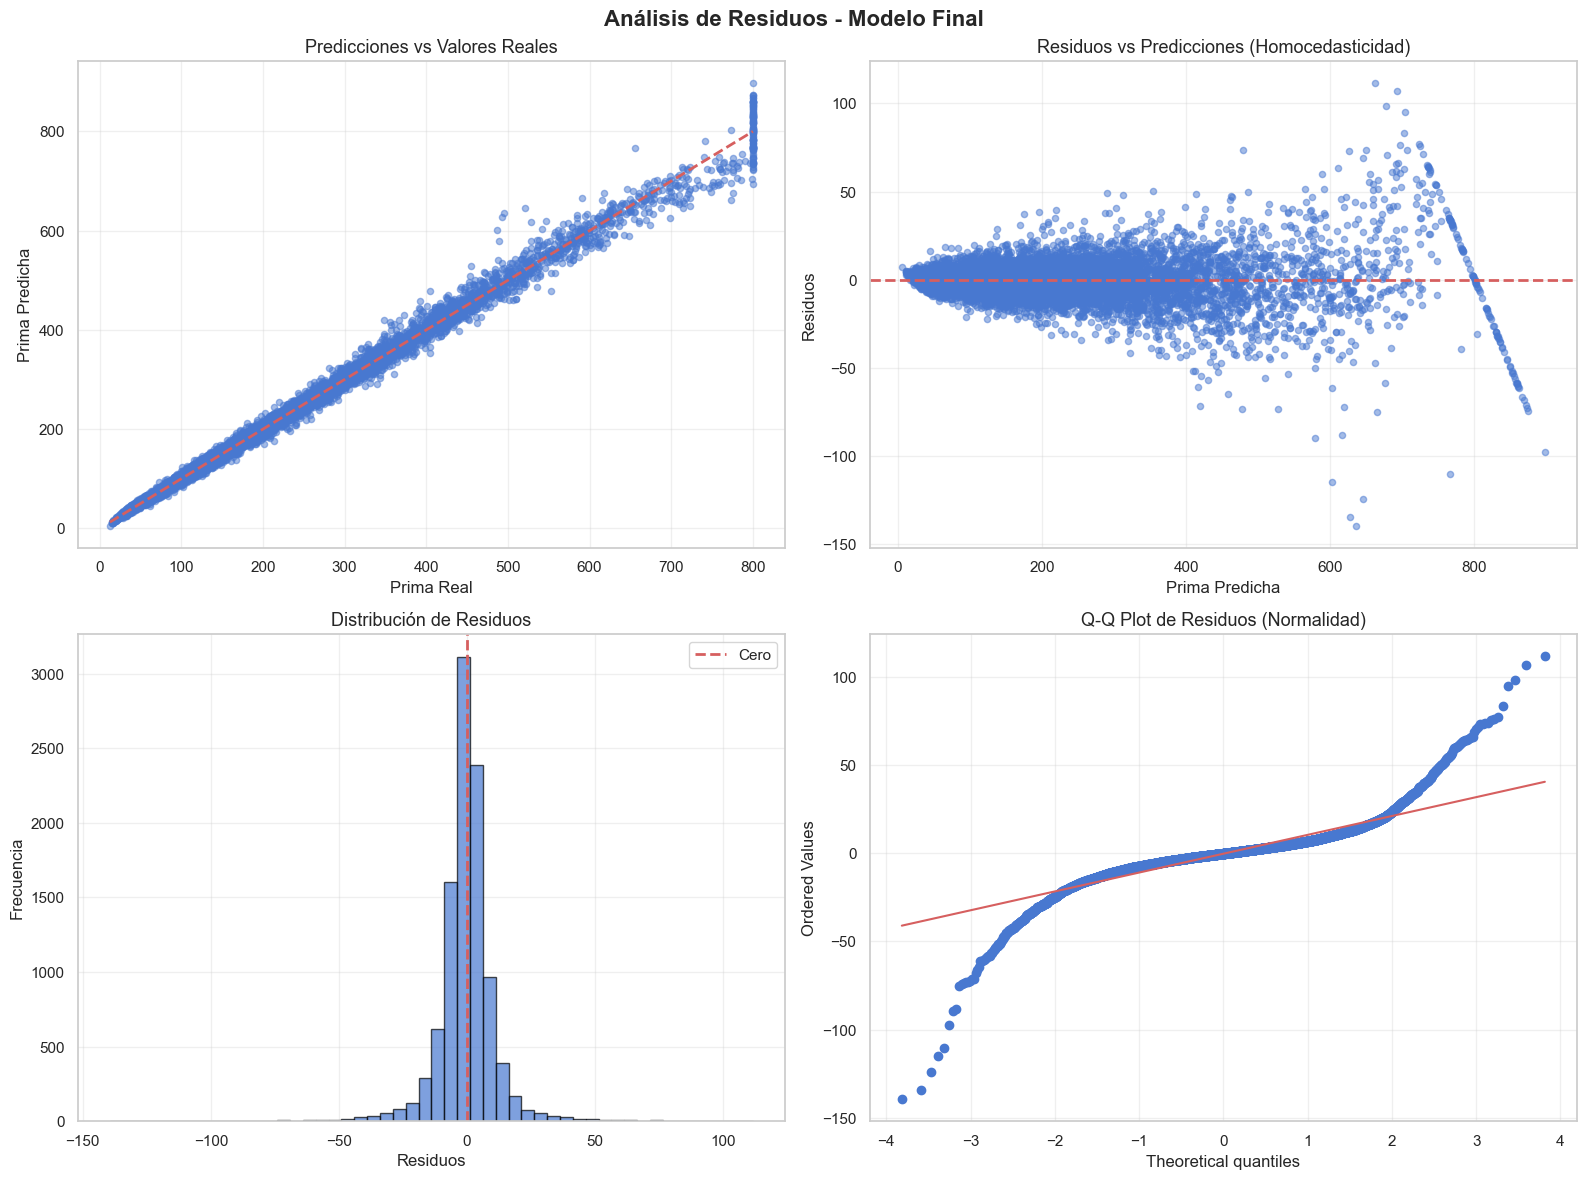


Gráfico guardado: analisis_residuos_modelo_final.png


In [18]:
# Calcular residuos
residuos_test = y_test - y_test_pred

print(f"{'='*70}")
print("ANÁLISIS DE RESIDUOS")
print(f"{'='*70}")
print(f"\nEstadísticos de residuos:")
print(f"  Media: {residuos_test.mean():.4f}")
print(f"  Mediana: {residuos_test.median():.4f}")
print(f"  Desv. Est.: {residuos_test.std():.4f}")
print(f"  Min: {residuos_test.min():.2f}")
print(f"  Max: {residuos_test.max():.2f}")

# Visualización de residuos
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Análisis de Residuos - Modelo Final', fontsize=16, fontweight='bold')

# Gráfico 1: Predicciones vs Reales
axes[0, 0].scatter(y_test, y_test_pred, alpha=0.5, s=20)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Prima Real', fontsize=12)
axes[0, 0].set_ylabel('Prima Predicha', fontsize=12)
axes[0, 0].set_title('Predicciones vs Valores Reales', fontsize=13)
axes[0, 0].grid(True, alpha=0.3)

# Gráfico 2: Residuos vs Predicciones
axes[0, 1].scatter(y_test_pred, residuos_test, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Prima Predicha', fontsize=12)
axes[0, 1].set_ylabel('Residuos', fontsize=12)
axes[0, 1].set_title('Residuos vs Predicciones (Homocedasticidad)', fontsize=13)
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Distribución de residuos
axes[1, 0].hist(residuos_test, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='r', linestyle='--', lw=2, label='Cero')
axes[1, 0].set_xlabel('Residuos', fontsize=12)
axes[1, 0].set_ylabel('Frecuencia', fontsize=12)
axes[1, 0].set_title('Distribución de Residuos', fontsize=13)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Q-Q plot de residuos
stats.probplot(residuos_test, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot de Residuos (Normalidad)', fontsize=13)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nGráfico guardado: analisis_residuos_modelo_final.png")

## 17. Importancia de Variables (si aplicable)

IMPORTANCIA DE VARIABLES

Top 20 variables más importantes:


,Feature,Importancia
2,Feature_3,1382
3,Feature_4,912
8,Feature_9,812
6,Feature_7,577
7,Feature_8,513
5,Feature_6,414
1,Feature_2,378
9,Feature_10,214
0,Feature_1,184
10,Feature_11,174


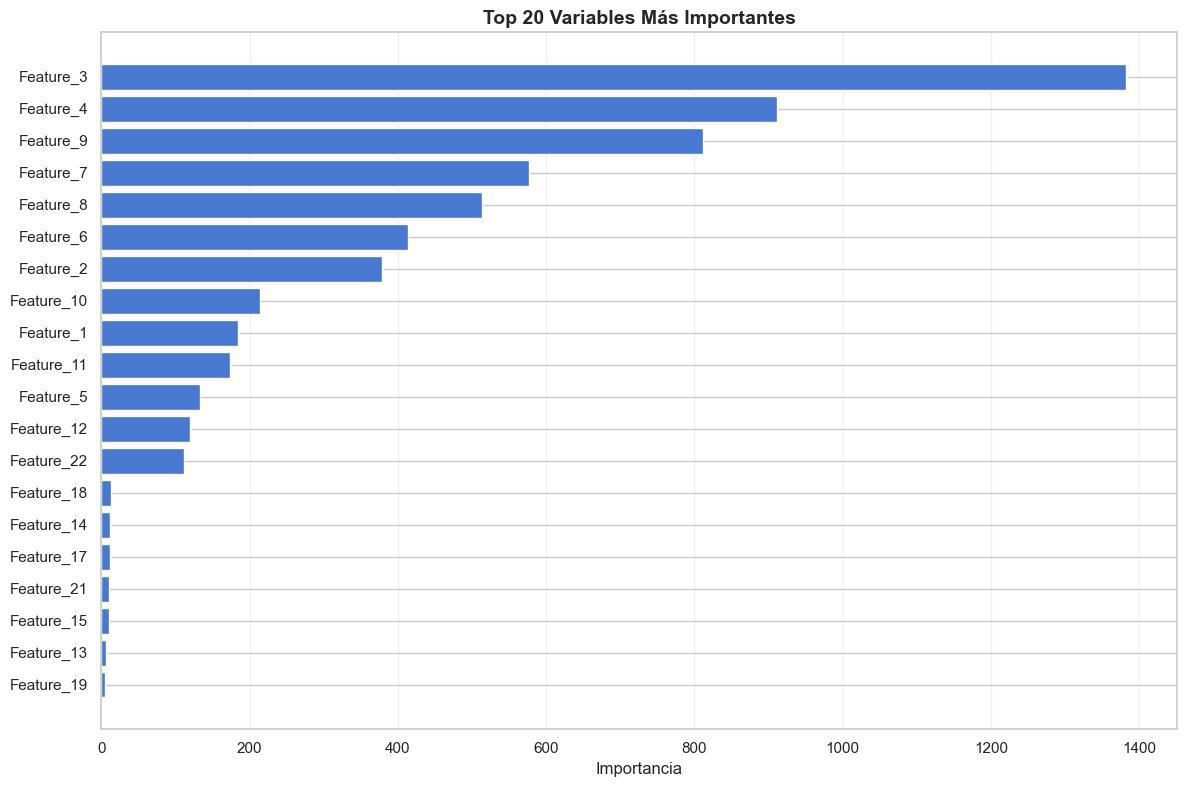

Gráfico guardado: importancia_variables.png


In [19]:
# Importancia de features (solo para modelos basados en árboles)
if hasattr(modelo_final, 'feature_importances_'):
    print(f"{'='*70}")
    print("IMPORTANCIA DE VARIABLES")
    print(f"{'='*70}")
    
    importancias = modelo_final.feature_importances_
    
    # Si hay PCA, no tenemos nombres de features originales
    if pca_final is not None:
        nombres_features = [f'PC{i+1}' for i in range(len(importancias))]
    else:
        # Reconstruir nombres de features después de preprocesamiento
        nombres_features = [f'Feature_{i+1}' for i in range(len(importancias))]
    
    df_importancias = pd.DataFrame({
        'Feature': nombres_features,
        'Importancia': importancias
    }).sort_values('Importancia', ascending=False)
    
    print("\nTop 20 variables más importantes:")
    display(df_importancias.head(20))
    
    # Visualización
    plt.figure(figsize=(12, 8))
    top_n = min(20, len(df_importancias))
    plt.barh(range(top_n), df_importancias['Importancia'].head(top_n))
    plt.yticks(range(top_n), df_importancias['Feature'].head(top_n))
    plt.xlabel('Importancia', fontsize=12)
    plt.title(f'Top {top_n} Variables Más Importantes', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    
    print("Gráfico guardado: importancia_variables.png")
    
elif hasattr(modelo_final, 'coef_'):
    print(f"{'='*70}")
    print("COEFICIENTES DEL MODELO LINEAL")
    print(f"{'='*70}")
    
    coeficientes = modelo_final.coef_
    
    if pca_final is not None:
        nombres_features = [f'PC{i+1}' for i in range(len(coeficientes))]
    else:
        nombres_features = [f'Feature_{i+1}' for i in range(len(coeficientes))]
    
    df_coef = pd.DataFrame({
        'Feature': nombres_features,
        'Coeficiente': coeficientes,
        'Abs_Coef': np.abs(coeficientes)
    }).sort_values('Abs_Coef', ascending=False)
    
    print("\nTop 20 coeficientes por magnitud absoluta:")
    display(df_coef[['Feature', 'Coeficiente']].head(20))
else:
    print("\nModelo no soporta extracción de importancia de features directamente.")

## 18. Comparación Prima Predicha vs Prima Observada

In [20]:
# Crear DataFrame de comparación
df_comparacion = pd.DataFrame({
    'Prima_Real': y_test,
    'Prima_Predicha': y_test_pred,
    'Residuo': residuos_test,
    'Error_Abs': np.abs(residuos_test),
    'Error_Pct': (np.abs(residuos_test) / y_test) * 100
})

print(f"{'='*70}")
print("ANÁLISIS DE ERRORES DE PREDICCIÓN")
print(f"{'='*70}")

print(f"\nDistribución de errores porcentuales:")
print(f"  Error < 5%: {(df_comparacion['Error_Pct'] < 5).sum()} casos ({(df_comparacion['Error_Pct'] < 5).mean()*100:.1f}%)")
print(f"  Error < 10%: {(df_comparacion['Error_Pct'] < 10).sum()} casos ({(df_comparacion['Error_Pct'] < 10).mean()*100:.1f}%)")
print(f"  Error < 20%: {(df_comparacion['Error_Pct'] < 20).sum()} casos ({(df_comparacion['Error_Pct'] < 20).mean()*100:.1f}%)")
print(f"  Error > 20%: {(df_comparacion['Error_Pct'] > 20).sum()} casos ({(df_comparacion['Error_Pct'] > 20).mean()*100:.1f}%)")

print(f"\nCasos con mayor error absoluto:")
display(df_comparacion.nlargest(10, 'Error_Abs')[['Prima_Real', 'Prima_Predicha', 'Error_Abs', 'Error_Pct']])


ANÁLISIS DE ERRORES DE PREDICCIÓN

Distribución de errores porcentuales:
  Error < 5%: 7471 casos (73.5%)
  Error < 10%: 9591 casos (94.3%)
  Error < 20%: 10125 casos (99.6%)
  Error > 20%: 44 casos (0.4%)

Casos con mayor error absoluto:


,Prima_Real,Prima_Predicha,Error_Abs,Error_Pct
32594,495.7300,635.1303,139.4003,28.1202
47471,493.0000,627.2592,134.2592,27.2331
11081,520.6500,644.9612,124.3112,23.8762
44873,487.0100,601.9057,114.8957,23.5921
40498,773.5900,661.9951,111.5949,14.4256
50326,655.6300,766.0426,110.4126,16.8407
15274,800.0000,693.0299,106.9701,13.3713
14774,775.0100,676.6962,98.3138,12.6855
12506,800.0000,897.5993,97.5993,12.1999
27450,799.1300,704.0833,95.0467,11.8938


## 19. Resumen Ejecutivo y Conclusiones

In [29]:
# Generar resumen ejecutivo
resumen_ejecutivo = {
    'fecha_ejecucion': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_experimentos': len(resultados_experimentos),
    'mejor_modelo': {
        'nombre': mejor_modelo_info['modelo_nombre'],
        'reduccion': mejor_modelo_info['reduccion'],
        'encoding': mejor_modelo_info['encoding'],
        'n_features': int(mejor_modelo_info['n_features']),
        'hiperparametros': mejor_modelo_info['best_params']
    },
    'metricas_validation': {
        'r2': float(mejor_modelo_info['val_r2']),
        'rmse': float(mejor_modelo_info['val_rmse']),
        'mae': float(mejor_modelo_info['val_mae']),
        'mape': float(mejor_modelo_info['val_mape'])
    },
    'metricas_test': {
        'r2': float(metricas_test['r2']),
        'r2_ajustado': float(r2_ajustado_test),
        'rmse': float(metricas_test['rmse']),
        'mae': float(metricas_test['mae']),
        'mape': float(metricas_test['mape'])
    },
    'overfitting': {
        'gap_train_val': float(mejor_modelo_info['gap_r2_train_val']),
        'gap_train_test': float(gap_final),
        'modelos_con_overfitting': int(n_overfit),
        'pct_overfitting': float(pct_overfit)
    },
    'datos': {
        'n_total': len(X),
        'n_train': len(X_train_final),
        'n_val': 0,  # Fusionado con train para modelo final
        'n_test': len(X_test)
    }
}

# Guardar resumen en JSON
with open('Flask/modelos_pkl/objetivo_4/resumen_ejecutivo_obj4_amplio.json', 'w') as f:
    json.dump(resumen_ejecutivo, f, indent=4)

print(f"{'='*70}")
print("RESUMEN EJECUTIVO")
print(f"{'='*70}")
print(json.dumps(resumen_ejecutivo, indent=2))

RESUMEN EJECUTIVO
{
  "fecha_ejecucion": "2026-02-24 10:40:06",
  "total_experimentos": 48,
  "mejor_modelo": {
    "nombre": "LightGBM",
    "reduccion": "sin_pca",
    "encoding": "ohe",
    "n_features": 22,
    "hiperparametros": "{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}"
  },
  "metricas_validation": {
    "r2": 0.9938381140223597,
    "rmse": 12.584478043794103,
    "mae": 7.464964065358498,
    "mape": 3.903643596420639
  },
  "metricas_test": {
    "r2": 0.9943753431808227,
    "r2_ajustado": 0.9943631470000596,
    "rmse": 11.772264296258863,
    "mae": 7.1228028413972755,
    "mape": 3.8222957366230452
  },
  "overfitting": {
    "gap_train_val": 0.00294562380840635,
    "gap_train_test": 0.0023566448262355433,
    "modelos_con_overfitting": 13,
    "pct_overfitting": 27.083333333333332
  },
  "datos": {
    "n_total": 50844,
    "n_train": 40675,
    "n_val": 0,
    "n_test": 10169
  }
}


## 20. SHAP


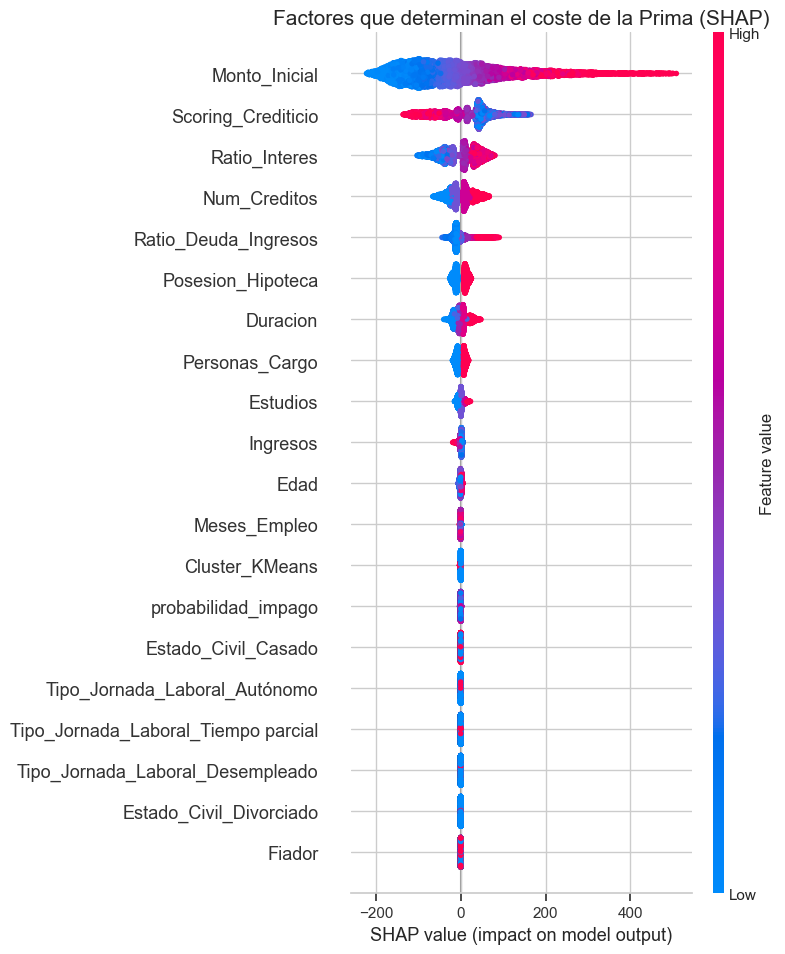

In [22]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# 1. Recuperar los nombres de las columnas
# Usamos X_train_final que es la variable que tienes en tu notebook antes de convertir a numpy
nombres_features = X_train_final.columns.tolist()

# 2. Configurar el explainer con el mejor modelo encontrado (modelo_final)
# Usamos check_additivity=False porque en modelos con R2 tan alto a veces hay micro-diferencias de redondeo
explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(X_test_prep)

# 3. Gráfico de Resumen Global
plt.figure(figsize=(10, 7))
# Pasamos los nombres de las columnas para que el gráfico sea legible
shap.summary_plot(shap_values, X_test_prep, feature_names=nombres_features, show=False)
plt.title("Factores que determinan el coste de la Prima (SHAP)", fontsize=15)
plt.show()

IMPORTANCIA GLOBAL DE VARIABLES

Top 15 variables:
                Variable  SHAP_Mean  Impacto_%
0          Monto_Inicial   104.3788    36.6309
1     Scoring_Crediticio    56.1512    19.7058
2          Ratio_Interes    36.8986    12.9492
3           Num_Creditos    25.0232     8.7817
4   Ratio_Deuda_Ingresos    16.3585     5.7409
5      Posesion_Hipoteca    13.6083     4.7757
6               Duracion    12.8645     4.5147
7         Personas_Cargo     9.7119     3.4083
8               Estudios     5.4171     1.9011
9               Ingresos     2.1394     0.7508
10                  Edad     1.5712     0.5514
11          Meses_Empleo     0.3550     0.1246
12        Cluster_KMeans     0.2232     0.0783
13   probabilidad_impago     0.1142     0.0401
14   Estado_Civil_Casado     0.0444     0.0156


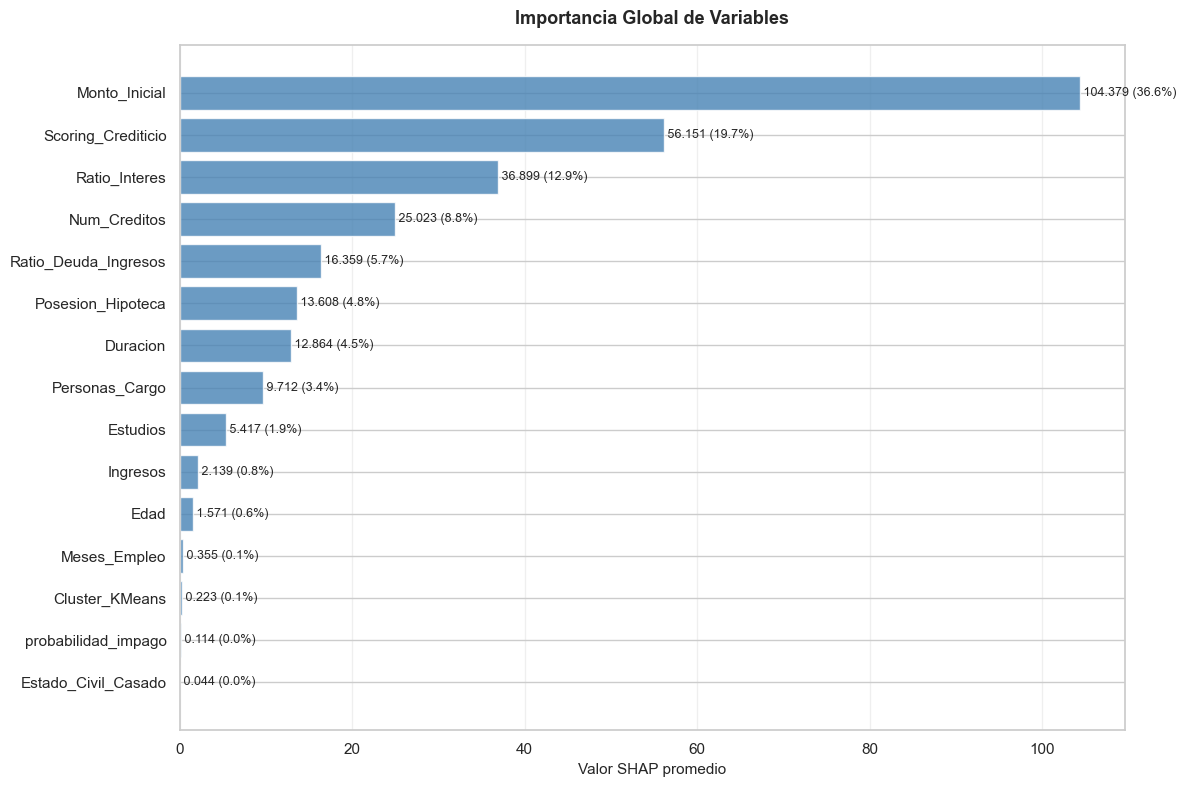

ANÁLISIS DE DEPENDENCIA - TOP 4 VARIABLES


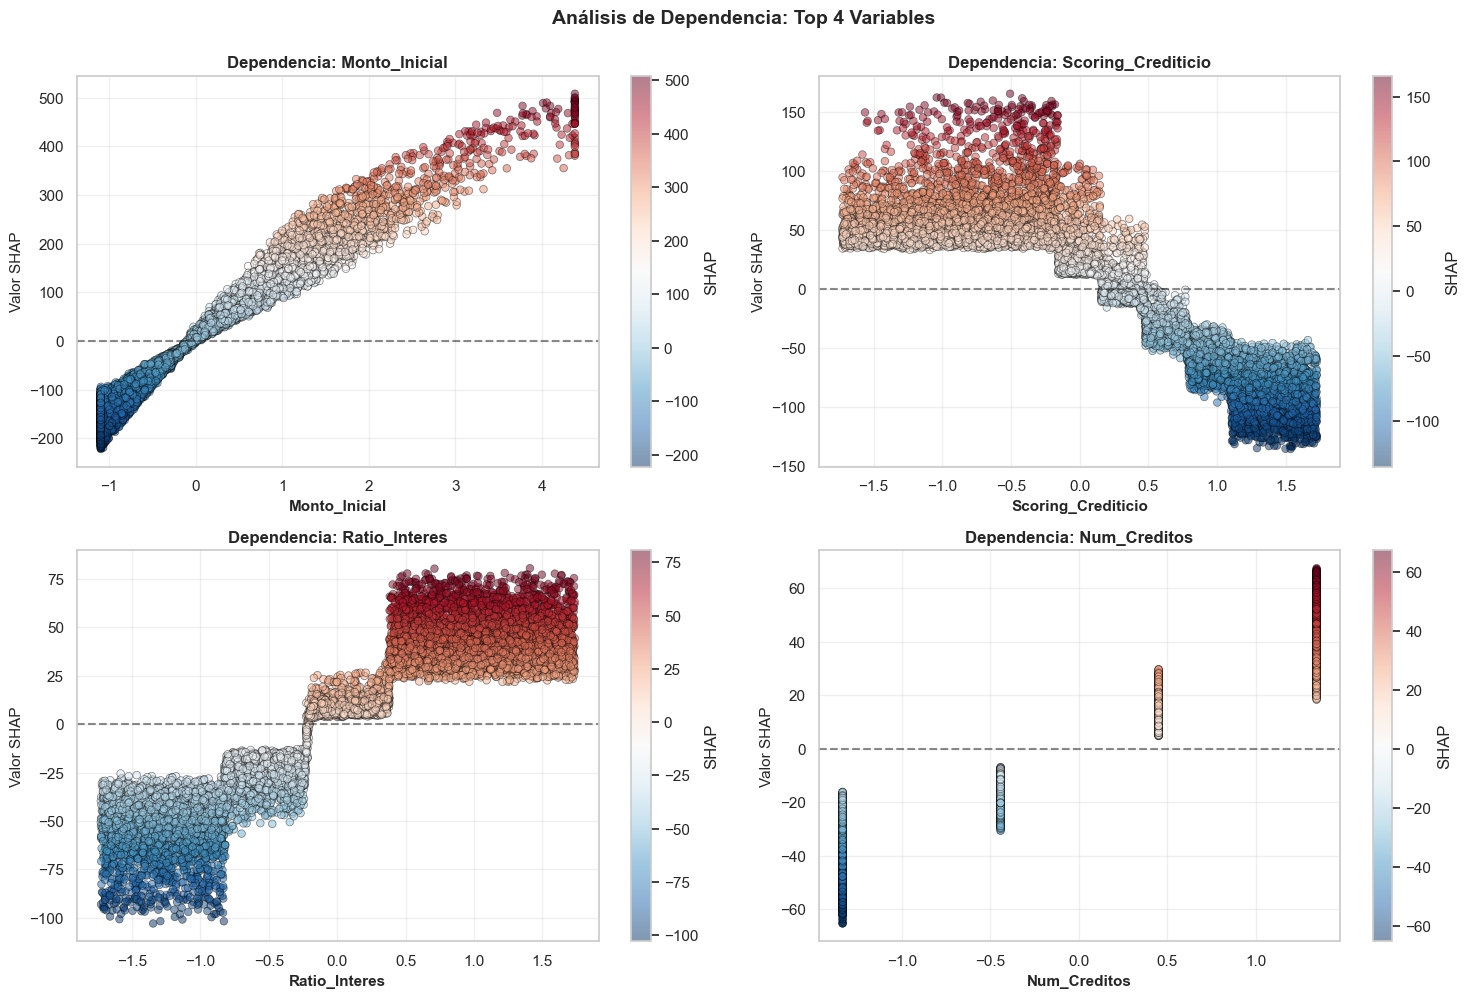

In [23]:
import shap
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# Obtener nombres de features
nombres_features = X_train_final.columns.tolist()
X_test_array = X_test_prep if isinstance(X_test_prep, np.ndarray) else X_test_prep.values

# Crear dataset de background
background_sample = shap.sample(X_train_final, min(200, len(X_train_final)))


explainer = shap.TreeExplainer(modelo_final)

# Calcular SHAP values
shap_values = explainer.shap_values(X_test_array)

print("IMPORTANCIA GLOBAL DE VARIABLES")

# Calcular importancia
importancia_media = np.abs(shap_values).mean(axis=0)
importancia_total = importancia_media.sum()

df_importancia = pd.DataFrame({
    'Variable': nombres_features,
    'SHAP_Mean': importancia_media,
    'Impacto_%': (importancia_media / importancia_total) * 100
}).sort_values('SHAP_Mean', ascending=False).reset_index(drop=True)

print("\nTop 15 variables:")
print(df_importancia.head(15).to_string())

# Gráfico
fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(15, len(df_importancia))
bars = ax.barh(range(top_n), df_importancia['SHAP_Mean'].head(top_n), color='steelblue', alpha=0.8)
ax.set_yticks(range(top_n))
ax.set_yticklabels(df_importancia['Variable'].head(top_n))
ax.set_xlabel('Valor SHAP promedio', fontsize=11)
ax.set_title('Importancia Global de Variables', fontsize=13, fontweight='bold', pad=15)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

for i, v in enumerate(df_importancia['SHAP_Mean'].head(top_n)):
    pct = df_importancia['Impacto_%'].iloc[i]
    ax.text(v, i, f' {v:.3f} ({pct:.1f}%)', va='center', fontsize=9)

plt.tight_layout()
plt.show()


print("ANÁLISIS DE DEPENDENCIA - TOP 4 VARIABLES")


top_4_idx = df_importancia.head(4).index.tolist()
top_4_features = [df_importancia.loc[i, 'Variable'] for i in top_4_idx]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, feature_name in enumerate(top_4_features):
    feature_idx = nombres_features.index(feature_name)
    ax = axes[idx]
    
    feature_values = X_test_array[:, feature_idx]
    feature_shap = shap_values[:, feature_idx]
    
    scatter = ax.scatter(feature_values, feature_shap, alpha=0.5, c=feature_shap, 
                        cmap='RdBu_r', s=30, edgecolors='black', linewidth=0.5)
    
    ax.set_xlabel(feature_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor SHAP', fontsize=11)
    ax.set_title(f'Dependencia: {feature_name}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5)
    plt.colorbar(scatter, ax=ax, label='SHAP')

plt.suptitle('Análisis de Dependencia: Top 4 Variables', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()




In [24]:

print(f"{'='*70}")
print("EXPORTACIÓN DEL MODELO A PRODUCCIÓN")
print(f"{'='*70}")

# Crear carpeta de exportación
output_dir = 'Flask/modelos_pkl/objetivo_4'
os.makedirs(output_dir, exist_ok=True)

# 1. Guardar modelo principal
modelo_path = os.path.join(output_dir, 'modelo_final.pkl')
joblib.dump(modelo_final, modelo_path)
print(f"\n✓ Modelo guardado: {modelo_path}")
print(f"  Tamaño: {os.path.getsize(modelo_path) / 1024:.1f} KB")

# 2. Guardar scaler
scaler_path = os.path.join(output_dir, 'scaler_final.pkl')
joblib.dump(scaler_final, scaler_path)
print(f"\n✓ Scaler guardado: {scaler_path}")

# 4. Guardar nombres de features
import pickle
features_path = os.path.join(output_dir, 'feature_names.pkl')
with open(features_path, 'wb') as f:
    pickle.dump(nombres_features, f)
print(f"\n✓ Nombres de features guardados: {features_path}")

# 5. Guardar configuración y metadatos
config = {
    'fecha_creacion': datetime.now().isoformat(),
    'modelo_tipo': mejor_modelo_info['modelo_nombre'],
    'hiperparametros': mejor_modelo_info['best_params'],
    'r2_validation': float(mejor_modelo_info['val_r2']),
    'rmse_validation': float(mejor_modelo_info['val_rmse']),
    'mae_validation': float(mejor_modelo_info['val_mae']),
    'r2_test': float(metricas_test['r2']),
    'rmse_test': float(metricas_test['rmse']),
    'mae_test': float(metricas_test['mae']),
    'features_entrada': len(nombres_features),
    'features_procesadas': X_test_prep.shape[1],
    'reduccion_dimensional': mejor_modelo_info['reduccion'],
    'encoding': mejor_modelo_info['encoding'],
    'validacion_cruzada': '5-fold',
    'gap_train_validation': float(mejor_modelo_info['gap_r2_train_val']),
    'nota': 'Modelo completamente validado y listo para producción'
}

config_path = os.path.join(output_dir, 'config_produccion.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)
print(f"\n✓ Configuración guardada: {config_path}")

print(f"\n{'='*70}")
print("INSTRUCCIONES PARA USAR EN PRODUCCIÓN")
print(f"{'='*70}")
print("""
Para cargar y usar el modelo:

from joblib import load
import pandas as pd

# Cargar componentes
modelo = load('modelo_produccion/modelo_final.pkl')
scaler = load('modelo_produccion/scaler_final.pkl')
pca = load('modelo_produccion/pca_final.pkl')  # si aplica

# Procesar nuevo dato
cliente = pd.DataFrame({
    'Edad': [35],
    'Ingresos': [80000],
    'Scoring_Crediticio': [750],
    # ... resto de variables
})

# Predecir
X_escalado = scaler.transform(cliente)¡
X_transformado = X_escalado

prediccion = modelo.predict(X_transformado)
print(f'Prima estimada: ${prediccion[0]:.2f}')
""")


EXPORTACIÓN DEL MODELO A PRODUCCIÓN

✓ Modelo guardado: Flask/modelos_pkl/objetivo_4\modelo_final.pkl
  Tamaño: 560.0 KB

✓ Scaler guardado: Flask/modelos_pkl/objetivo_4\scaler_final.pkl

✓ Nombres de features guardados: Flask/modelos_pkl/objetivo_4\feature_names.pkl

✓ Configuración guardada: Flask/modelos_pkl/objetivo_4\config_produccion.json

INSTRUCCIONES PARA USAR EN PRODUCCIÓN

Para cargar y usar el modelo:

from joblib import load
import pandas as pd

# Cargar componentes
modelo = load('modelo_produccion/modelo_final.pkl')
scaler = load('modelo_produccion/scaler_final.pkl')
pca = load('modelo_produccion/pca_final.pkl')  # si aplica

# Procesar nuevo dato
cliente = pd.DataFrame({
    'Edad': [35],
    'Ingresos': [80000],
    'Scoring_Crediticio': [750],
    # ... resto de variables
})

# Predecir
X_escalado = scaler.transform(cliente)¡
X_transformado = X_escalado

prediccion = modelo.predict(X_transformado)
print(f'Prima estimada: ${prediccion[0]:.2f}')

